# DSP Exercise #1

## 201910936 김연수

In [53]:
# Get thinkdsp.py

import os

if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py
    
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio

from thinkdsp import read_wave

%matplotlib inline

In [54]:
#directly connected to certain wav
filename = 'temp.wav'

wave = read_wave(filename)

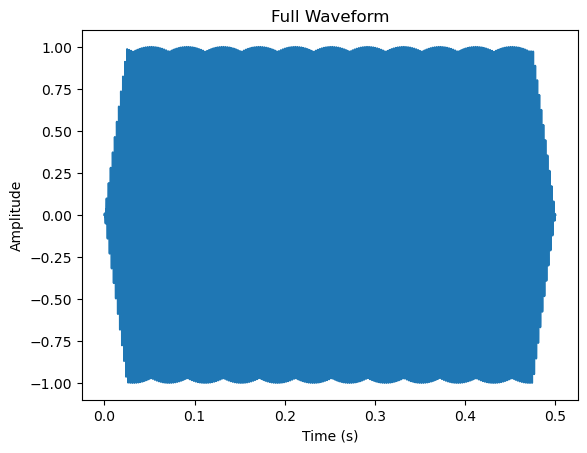

In [59]:
# Entire Wave Form
wave.plot()
plt.title('Full Waveform')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

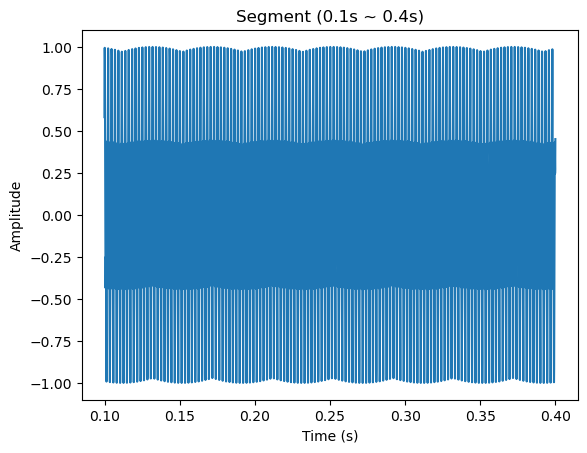

In [60]:
# adjusting start-end point manually
start = 0.1
end   = 0.4

segment = wave.segment(start=start, duration= end-start)

# Plot the segment
segment.plot()
plt.title(f'Segment ({start}s ~ {end}s)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

# Listen to the segment
segment.make_audio()

### 그래프가 전체적으로 동일한 형태로 보여지는 것과 유사하게 소리 또한 동일한 음이 일정하게 유지된다.

## (1) Compute and Plot the Spectrum

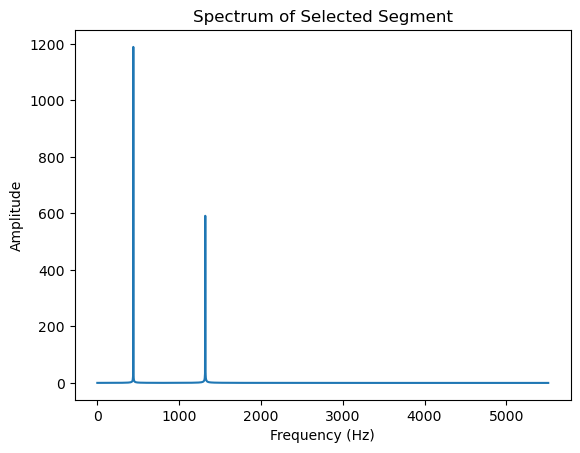

In [62]:
spectrum = segment.make_spectrum()

spectrum.plot()
plt.title('Spectrum of Selected Segment')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.show()

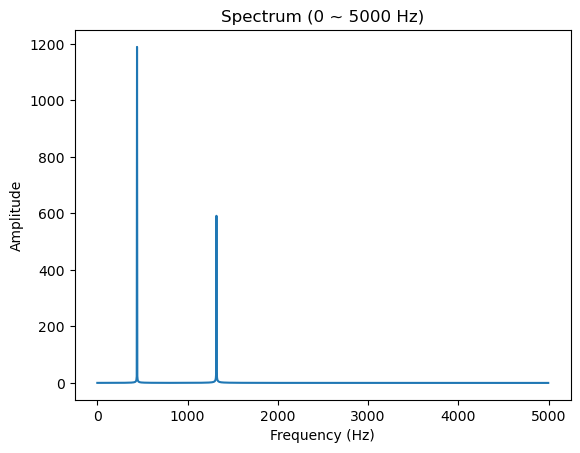

In [63]:
spectrum.plot(high=5000)
plt.title('Spectrum (0 ~ 5000 Hz)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.show()

## (2) Filters
### High-Pass Filter

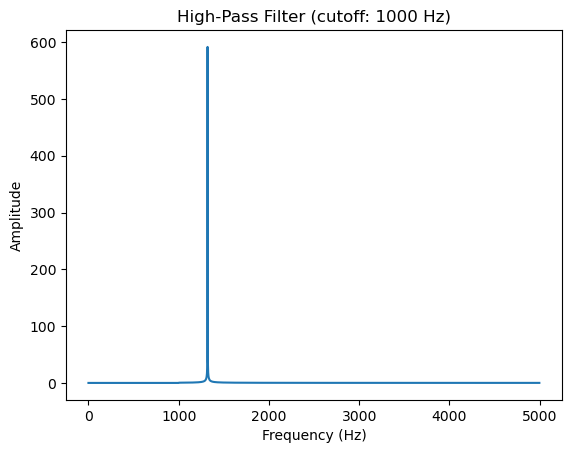

In [64]:
cutoff_high = 1000

spectrum_hp = segment.make_spectrum()
spectrum_hp.high_pass(cutoff_high)

# Plot filtered spectrum
spectrum_hp.plot(high=5000)
plt.title(f'High-Pass Filter (cutoff: {cutoff_high} Hz)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.show()

wave_hp = spectrum_hp.make_wave()
wave_hp.make_audio()

### 1000 hz 이하를 제거한 결과, 높은 음이 강하게 들린다.

### Low-Pass Filter

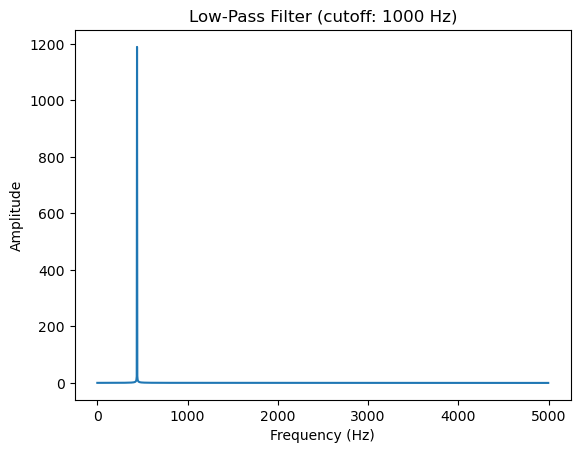

In [69]:
cutoff_low = 1000 

spectrum_lp = segment.make_spectrum()
spectrum_lp.low_pass(cutoff_low)

# Plot filtered spectrum
spectrum_lp.plot(high=5000)
plt.title(f'Low-Pass Filter (cutoff: {cutoff_low} Hz)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.show()

# Convert back to wave and listen
wave_lp = spectrum_lp.make_wave()
wave_lp.make_audio()

### 1000hz 이상을 제거한 결과, 낮은 음이 강하게 들린다

### Band-Stop Filter

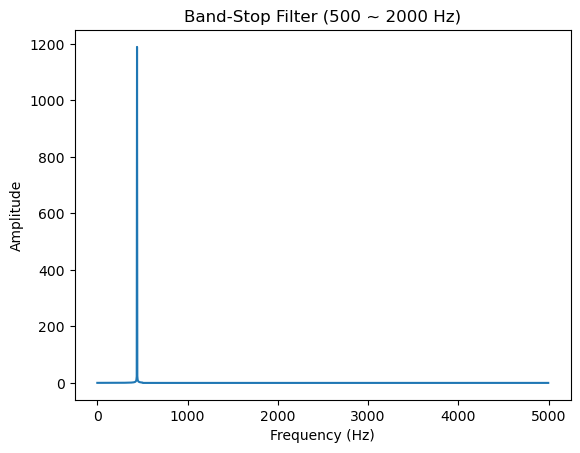

In [70]:
bs_low  = 500 
bs_high = 2000 

spectrum_bs = segment.make_spectrum()
spectrum_bs.band_stop(bs_low, bs_high)

# Plot filtered spectrum
spectrum_bs.plot(high=5000)
plt.title(f'Band-Stop Filter ({bs_low} ~ {bs_high} Hz)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.show()

# Convert back to wave and listen
wave_bs = spectrum_bs.make_wave()
wave_bs.make_audio()

### 500-2000hz 사이의 음만 유지한 결과, 1000~2000에 존재하던 고음이 사라진 Low-Pass Filter와 동일한 음이 들린다.